# 제주 농산물 가격 예측 최종 고도화 - EMA 0원 배제 버전 (GeminiCLI9.ipynb)

이 노트북은 MAE 성적이 가장 좋았던 GeminiCLI7을 기반으로 EMA 계산 방식을 개선한 버전입니다.
1. **EMA 0원 배제 (NaN Skip)**: 0원 데이터를 계산에서 제외하여 실제 거래 가격 기반의 순수 추세 학습
2. **변수 중요도 분석**: VotingRegressor 내 트리 모델들의 평균 기여도 시각화
3. **명절 접근 거리**: 설날/추석 전후 수요 변화 반영
4. **강력한 후처리**: TG 400원 임계값 + 전 품목 일요일 0원 처리 (CLI7의 점수 방어 전략 유지)
5. **5-Fold 교차 검증**: 로컬 MAE/RMSE 확인
6. **최종 결과물**: submission38.csv

## 1. 라이브러리 및 폰트 설정

In [1]:
import os
import pandas as pd
import numpy as np
import datetime
import holidays
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import VotingRegressor
from sklearn.linear_model import Ridge
from sklearn.model_selection import KFold
from sklearn.metrics import mean_absolute_error, mean_squared_error
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor
import warnings
warnings.filterwarnings("ignore")

try:
    from korean_font import set_korean_font
    set_korean_font()
    print("한글 폰트 설정 완료")
except:
    plt.rcParams['font.family'] = 'Malgun Gothic'
    plt.rcParams['axes.unicode_minus'] = False

한글 폰트 설정: NanumGothic (/usr/share/fonts/truetype/nanum/NanumGothic.ttf)
한글 폰트 설정 완료


## 2. 데이터 전처리

In [2]:
DATA_PATH = './data/'
train_raw = pd.read_csv(os.path.join(DATA_PATH, 'train.csv'))
test_raw = pd.read_csv(os.path.join(DATA_PATH, 'test.csv'))

outlier_thresholds = {'TG': 20000, 'RD': 5000, 'BC': 8000, 'CB': 2300}
for item, thr in outlier_thresholds.items():
    mask = (train_raw['item'] == item) & (train_raw['price(원/kg)'] > thr)
    if mask.any():
        mean_val = train_raw[(train_raw['item'] == item) & (train_raw['price(원/kg)'] > 0)]['price(원/kg)'].mean()
        train_raw.loc[mask, 'price(원/kg)'] = mean_val

print("이상치 처리 완료")

이상치 처리 완료


## 3. 특성 엔지니어링 (EMA 0원 제거 분석)

In [3]:
SEOLLAL_DATES = [pd.Timestamp(d) for d in ['2019-02-05', '2020-01-25', '2021-02-12', '2022-02-01', '2023-01-22']]
CHUSEOK_DATES = [pd.Timestamp(d) for d in ['2019-09-13', '2020-10-01', '2021-09-21', '2022-09-10', '2023-09-29']]

def add_features(df):
    df['timestamp'] = pd.to_datetime(df['timestamp'])
    df['year'] = df['timestamp'].dt.year
    df['month'] = df['timestamp'].dt.month
    df['day'] = df['timestamp'].dt.day
    df['dow'] = df['timestamp'].dt.dayofweek
    df['week_num'] = (df['timestamp'] - pd.to_datetime('2019-01-01')).dt.days // 7
    df['dist_seollal'] = df['timestamp'].map(lambda d: min(min(abs((d - h).days) for h in SEOLLAL_DATES), 30))
    df['dist_chuseok'] = df['timestamp'].map(lambda d: min(min(abs((d - h).days) for h in CHUSEOK_DATES), 30))
    kr_holidays = holidays.KR()
    df['holiday'] = df['timestamp'].apply(lambda x: 1 if x in kr_holidays else 0)
    return df

train = add_features(train_raw)
test = add_features(test_raw)

# 전체 품목 공휴일 보정
no_holi_dates = train[(train['holiday'] == 1) & (train['price(원/kg)'] > 0)]['timestamp'].unique()
train.loc[train['timestamp'].isin(no_holi_dates), 'holiday'] = 0
test.loc[test['timestamp'].isin(no_holi_dates), 'holiday'] = 0

def calculate_skip_zero_ema(series, window):
    # 0원을 NaN으로 변환하여 EMA 계산 시 완전히 제외 (Ignore NaN logic)
    s = series.replace(0, np.nan)
    # ewm은 기본적으로 NaN을 건너뜀 (가중치 계산에서 제외)
    ema = s.shift(1).ewm(span=window, min_periods=1).mean()
    # 계산 후 생긴 빈칸(0원이었던 날의 EMA)은 직전의 유효한 EMA 값으로 채움
    return ema.ffill().fillna(0)

print("EMA (0원 제거 분석) 계산 중...")
for w in [7, 30]:
    train[f'ema_{w}'] = train.groupby(['item', 'corporation', 'location'])['price(원/kg)'].transform(lambda x: calculate_skip_zero_ema(x, w))

last_ema = train.groupby(['item', 'corporation', 'location'])[[f'ema_{w}' for w in [7, 30]]].last().reset_index()
test = pd.merge(test, last_ema, on=['item', 'corporation', 'location'], how='left').fillna(0)

print("특성 엔지니어링 완료")

EMA (0원 제거 분석) 계산 중...
특성 엔지니어링 완료


## 4. 모델링 준비

In [4]:
le_cols = ['item', 'corporation', 'location']
le_dict = {col: LabelEncoder().fit(train[col]) for col in le_cols}
for col in le_cols:
    train[col] = le_dict[col].transform(train[col])
    test[col] = le_dict[col].transform(test[col])

item_codes = {name: le_dict['item'].transform([name])[0] for name in le_dict['item'].classes_}
train['target'] = np.where(train['item'] == item_codes['TG'], np.sqrt(train['price(원/kg)']), train['price(원/kg)'])

features = ['item', 'corporation', 'location', 'year', 'month', 'day', 'dow', 'week_num', 'holiday', 'dist_seollal', 'dist_chuseok', 'ema_7', 'ema_30']

scaler = StandardScaler()
train_scaled = pd.DataFrame(scaler.fit_transform(train[features]), columns=features)
test_scaled = pd.DataFrame(scaler.transform(test[features]), columns=features)
print("모델링 준비 완료")

모델링 준비 완료


## 5. 5-Fold 학습 및 변수 중요도 추출

Group 1: TG 학습...
Fold 1 | MAE: 1004.22
Fold 2 | MAE: 929.73
Fold 3 | MAE: 967.65
Fold 4 | MAE: 1019.47
Fold 5 | MAE: 994.46
==> TG Overall | MAE: 983.11 | RMSE: 1656.38


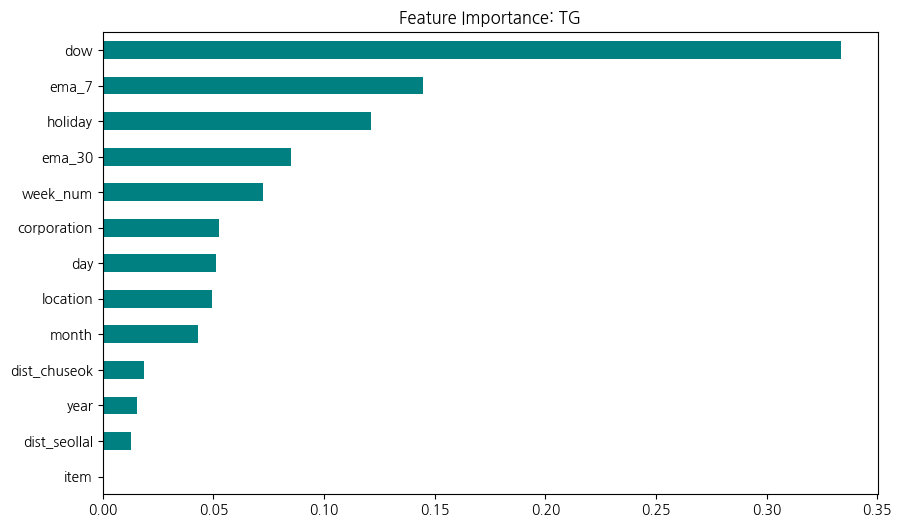

Group 2: RD & CR 학습...
Fold 1 | MAE: 142.48
Fold 2 | MAE: 144.39
Fold 3 | MAE: 140.82
Fold 4 | MAE: 139.85
Fold 5 | MAE: 139.27
==> RD_CR Overall | MAE: 141.36 | RMSE: 262.33


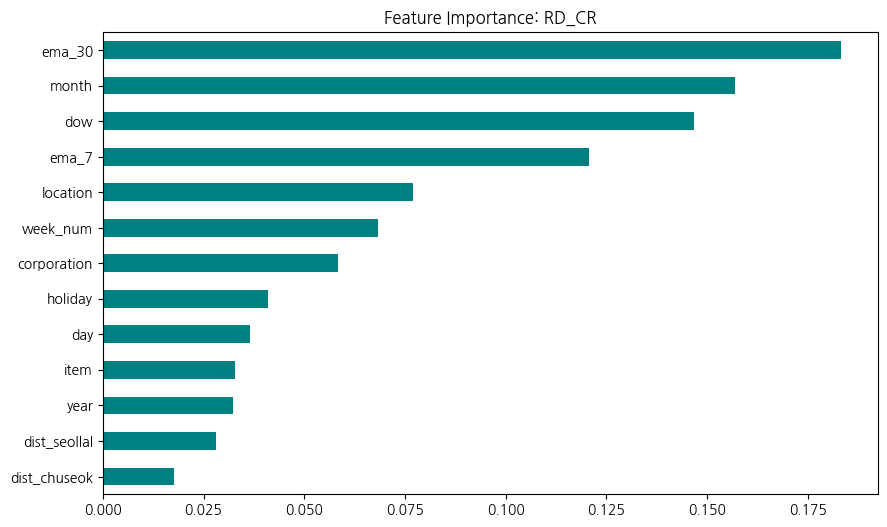

Group 3: BC & CB 학습...
Fold 1 | MAE: 290.19
Fold 2 | MAE: 290.32
Fold 3 | MAE: 292.30
Fold 4 | MAE: 286.97
Fold 5 | MAE: 297.95
==> BC_CB Overall | MAE: 291.55 | RMSE: 535.36


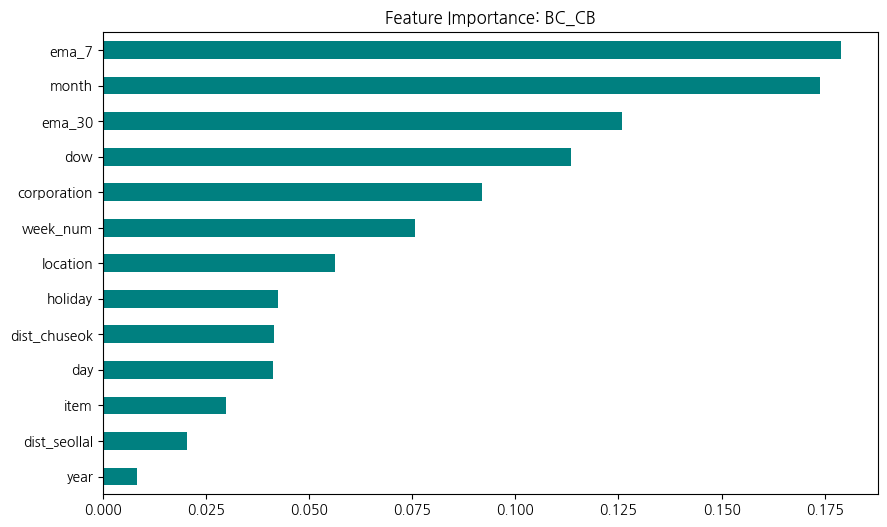

In [5]:
def train_group_with_importance(df, scaled_df, target_col, test_scaled_df, is_tg=False, group_name=""):
    df = df.reset_index(drop=True)
    scaled_df = scaled_df.reset_index(drop=True)
    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    fold_preds = []
    oof_preds = np.zeros(len(df))
    importances = pd.DataFrame(index=features)
    
    for fold, (train_idx, val_idx) in enumerate(kf.split(df)):
        X_train, y_train = scaled_df.iloc[train_idx], df[target_col].iloc[train_idx]
        X_val, y_val = scaled_df.iloc[val_idx], df[target_col].iloc[val_idx]
        
        ensemble = VotingRegressor([
            ('lgbm', LGBMRegressor(n_estimators=1000, learning_rate=0.01, random_state=42, verbose=-1)),
            ('xgb', XGBRegressor(n_estimators=1000, learning_rate=0.01, random_state=42)),
            ('cat', CatBoostRegressor(iterations=1000, learning_rate=0.01, random_state=42, verbose=0)),
            ('ridge', Ridge(alpha=1.0))
        ])
        
        ensemble.fit(X_train, y_train)
        val_pred = ensemble.predict(X_val)
        oof_preds[val_idx] = val_pred
        
        # 변수 중요도 추출
        lgbm_imp = ensemble.named_estimators_['lgbm'].feature_importances_
        xgb_imp = ensemble.named_estimators_['xgb'].feature_importances_
        cat_imp = ensemble.named_estimators_['cat'].get_feature_importance()
        importances[f'fold_{fold+1}'] = (lgbm_imp/lgbm_imp.sum() + xgb_imp/xgb_imp.sum() + cat_imp/cat_imp.sum()) / 3
        
        # 검증 점수 산출 (일요일 0원 보정 포함)
        y_val_orig = np.power(y_val, 2) if is_tg else y_val
        val_pred_orig = np.power(np.maximum(0, val_pred), 2) if is_tg else np.maximum(0, val_pred)
        val_pred_orig[df['dow'].iloc[val_idx].values == 6] = 0
        
        print(f"Fold {fold+1} | MAE: {mean_absolute_error(y_val_orig, val_pred_orig):.2f}")
        fold_preds.append(ensemble.predict(test_scaled_df))
    
    # 전체 결과
    oof_orig = np.power(np.maximum(0, oof_preds), 2) if is_tg else np.maximum(0, oof_preds)
    target_orig = np.power(df[target_col], 2) if is_tg else df[target_col]
    oof_orig[df['dow'].values == 6] = 0
    print(f"==> {group_name} Overall | MAE: {mean_absolute_error(target_orig, oof_orig):.2f} | RMSE: {np.sqrt(mean_squared_error(target_orig, oof_orig)):.2f}")
    
    # 중요도 시각화
    plt.figure(figsize=(10, 6))
    importances.mean(axis=1).sort_values().plot(kind='barh', color='teal', title=f'Feature Importance: {group_name}')
    plt.show()
    
    return np.mean(fold_preds, axis=0)

print("Group 1: TG 학습...")
tg_mask = train['item'] == item_codes['TG']
pred_tg = train_group_with_importance(train[tg_mask], train_scaled[tg_mask], 'target', test_scaled[test['item']==item_codes['TG']], True, "TG")

print("Group 2: RD & CR 학습...")
rd_cr_mask = train['item'].isin([item_codes['RD'], item_codes['CR']])
pred_rd_cr = train_group_with_importance(train[rd_cr_mask], train_scaled[rd_cr_mask], 'target', test_scaled[test['item'].isin([item_codes['RD'], item_codes['CR']])], False, "RD_CR")

print("Group 3: BC & CB 학습...")
bc_cb_mask = train['item'].isin([item_codes['BC'], item_codes['CB']])
pred_bc_cb = train_group_with_importance(train[bc_cb_mask], train_scaled[bc_cb_mask], 'target', test_scaled[test['item'].isin([item_codes['BC'], item_codes['CB']])], False, "BC_CB")

## 6. 후처리

In [6]:
test_tg = test[test['item'] == item_codes['TG']].copy()
test_rd_cr = test[test['item'].isin([item_codes['RD'], item_codes['CR']])].copy()
test_bc_cb = test[test['item'].isin([item_codes['BC'], item_codes['CB']])].copy()

test_tg['answer'] = np.power(np.maximum(0, pred_tg), 2)
test_rd_cr['answer'] = np.maximum(0, pred_rd_cr)
test_bc_cb['answer'] = np.maximum(0, pred_bc_cb)

# 최종 후처리 (TG 임계값 + 일요일 0원)
test_tg.loc[test_tg['answer'] < 400, 'answer'] = 0
for df in [test_tg, test_rd_cr, test_bc_cb]:
    df.loc[df['dow'] == 6, 'answer'] = 0

total_results = pd.concat([test_tg, test_rd_cr, test_bc_cb])
print("예측 및 후처리 완료")

예측 및 후처리 완료


## 7. 시각화 (최종 추세)

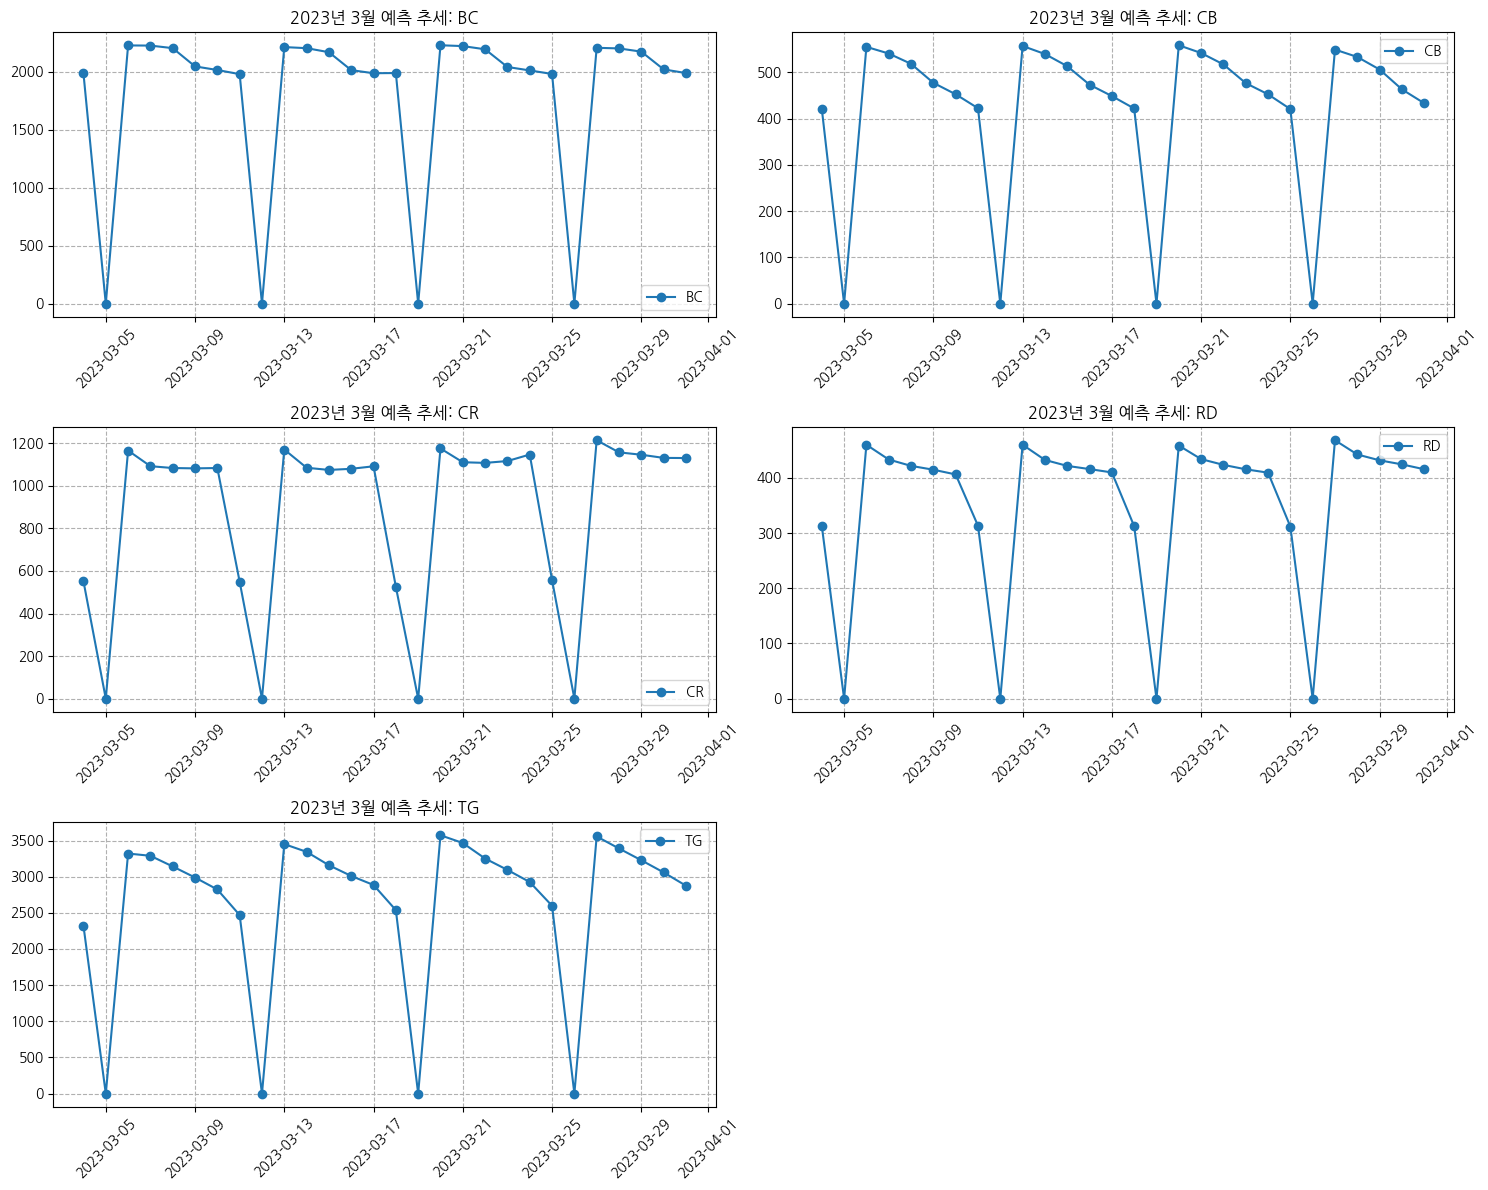

In [7]:
plt.figure(figsize=(15, 12))
items = le_dict['item'].classes_
for i, item_name in enumerate(items):
    plt.subplot(3, 2, i+1)
    item_code = le_dict['item'].transform([item_name])[0]
    data = total_results[total_results['item'] == item_code]
    daily = data.groupby('timestamp')['answer'].mean()
    plt.plot(daily.index, daily.values, marker='o', label=item_name)
    plt.title(f'2023년 3월 예측 추세: {item_name}')
    plt.xticks(rotation=45)
    plt.grid(True, linestyle='--')
    plt.legend()
plt.tight_layout()
plt.show()

## 8. 결과 저장

In [8]:
sample_sub = pd.read_csv(os.path.join(DATA_PATH, 'sample_submission.csv'))
submission = pd.merge(sample_sub[['ID']], total_results[['ID', 'answer']], on='ID', how='left')
submission.to_csv('submission38.csv', index=False)
print("submission38.csv 저장 완료")

submission38.csv 저장 완료
